<a href="https://colab.research.google.com/github/blgnr1/ML-Projects/blob/main/Ai-house-price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========================
🎯 PROJE GEREKSİNİMLERİ
========================

📊 KEŞİFSEL VERİ ANALİZİ (EDA)

Aşağıdaki analizleri yapman gerekiyor:

- Korelasyon Analizi:
  Özellikler ile hedef değişken (ev fiyatı) arasındaki ilişkiler

- Dağılım Analizi:
  Değişkenlerin nasıl dağıldığını inceleme


========================
🧹 VERİ ÖN İŞLEME
========================

Model kurmadan önce veriyi hazırla:

- Eksik Veri Yönetimi:
  Boş / null değerleri doldurma veya eleme

- Aykırı Değer Tespiti:
  Normalden çok farklı veri noktalarının bulunması

- Kategorik Değişken Dönüşümü:
  Metin verilerini sayısal hale getirme (encoding)

========================
🔎 FEATURE SELECTION
========================

Modeli iyileştirmek için:

- En önemli özellikleri seç
- Gereksiz özellikleri çıkar
- Model karmaşıklığını azalt
- Verileri normalize et

========================
🤖 MODEL EĞİTİMİ
========================

En az 4 farklı regresyon modeli dene:

- Linear Regression
- Random Forest
- Gradient Boosting
- XGBoost (veya benzeri)

NOT:
- "train" dosyası eğitim için kullanılacak
- "test" dosyası tahmin için kullanılacak


========================
📏 MODEL DEĞERLENDİRME
========================

Aşağıdaki metrikleri raporla:

- MAE (Mean Absolute Error)
  Ortalama mutlak hata

- RMSE (Root Mean Squared Error)
  Büyük hataları daha fazla cezalandırır

- R² Score
  Modelin açıklama gücü


========================
🔍 KRİTİK ANALİZ
========================

- Model en çok nerelerde hata yapıyor?
- Hangi ev tiplerini yanlış tahmin ediyor?

Özellikle:
- Lüks evler
- Çok eski evler
- Aykırı (outlier) evler


========================
🌍 GERÇEK HAYAT YORUMU
========================

- Bu model gerçek hayatta nasıl kullanılır?
- Emlak fiyat tahmini için ne kadar güvenilir?
- Hangi durumlarda başarısız olur?


========================
📦 TESLİM FORMATI
========================

- Jupyter Notebook (.ipynb)
  Tüm kodlar + grafikler + açıklamalar

- 5 Dakikalık Sunum Videosu
  Süreç özeti:
  - veri
  - model
  - sonuç
  - yorum

- Son teslim tarihi:
  13 Mayıs 2026

In [975]:
import zipfile
import os

zip_path = "/content/house-prices-advanced-regression-techniques.zip"
extract_path = "veriler"

# klasör oluştur
os.makedirs(extract_path, exist_ok=True)

# zip'i çıkar
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dosyalar çıkarıldı.")

Dosyalar çıkarıldı.


In [976]:
import pandas as pd
import numpy as np
submission = pd.read_csv("/content/veriler/sample_submission.csv")
submission.head(5)

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


In [977]:
test = pd.read_csv("/content/veriler/test.csv")
test.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [978]:
test.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [979]:
train = pd.read_csv("/content/veriler/train.csv")
train.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [980]:
train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [981]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [982]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


# 🏠 House Prices Dataset

---

## 📌 Genel Ev Bilgileri

### `MSSubClass`
Evin tipi / kat yapısı.

- `20` → Tek katlı yeni ev
- `60` → 2 katlı yeni ev
- `80` → Split / multi-level
- `90` → Dubleks

---

### `MSZoning`
İmar / bölge tipi.

- `RL` → Düşük yoğunluklu konut
- `RM` → Orta yoğunluklu konut
- `FV` → Lüks residential bölge
- `C` → Ticari alan

---

### `LotFrontage`
Yol cephesi uzunluğu.

### `LotArea`
Arsa büyüklüğü.

### `Neighborhood`
Mahalle / lokasyon bilgisi.

> Ev fiyatını en çok etkileyen feature'lardan biri.

---

# 🏡 Ev Yapısı

### `BldgType`
Ev tipi.

- `1Fam` → Müstakil ev
- `Duplx` → Dubleks
- `TwnhsE` → Köşe townhouse

---

### `HouseStyle`
Ev stili.

- `1Story` → Tek kat
- `2Story` → İki kat
- `SLvl` → Split level

---

### `OverallQual`
Genel kalite puanı.

- 1 → Çok kötü
- 10 → Çok kaliteli

> Datasetin en güçlü feature'larından biri.

---

### `OverallCond`
Genel kondisyon / durum puanı.

### `YearBuilt`
Yapım yılı.

### `YearRemodAdd`
Tadilat yılı.

---

# 🧱 Dış Yapı

### `RoofStyle`
Çatı tipi.

### `Exterior1st`
Dış cephe malzemesi.

### `ExterQual`
Dış kalite seviyesi.

```text
Ex > Gd > TA > Fa > Po

# 1.0 📊 KEŞİFSEL VERİ ANALİZİ (EDA)

## 1.1 Korelasyon Analizi

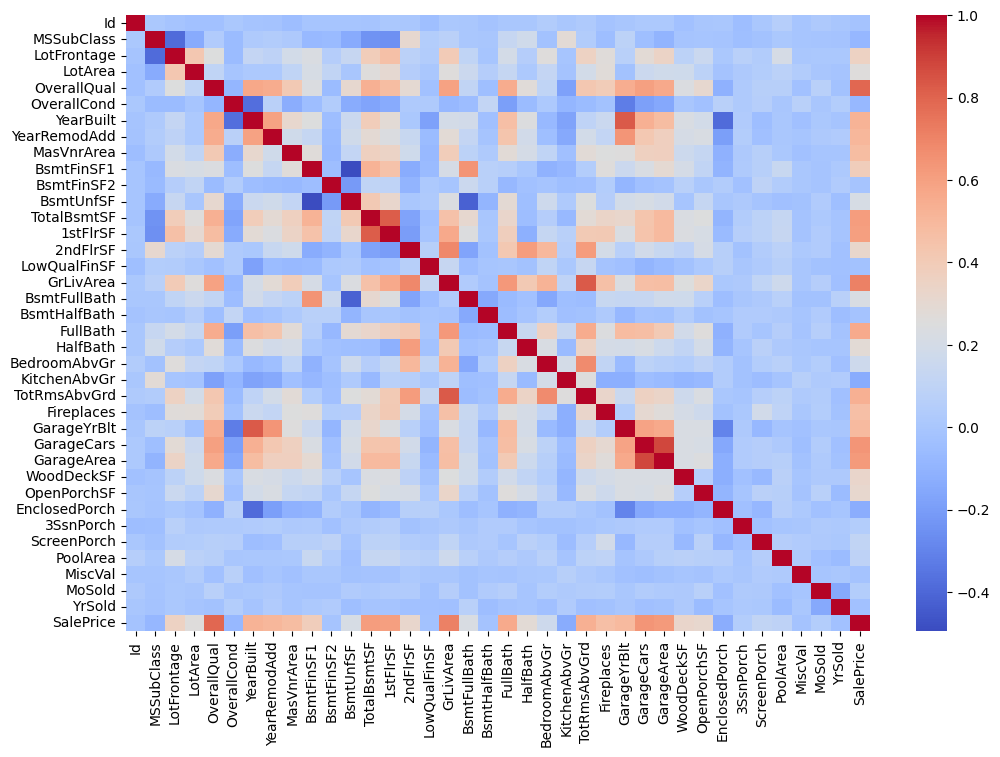

In [983]:
# Heatmap kullanarak tum korelasyonu gorup gorsellestirmis oluyoruz.
import seaborn as sns
import matplotlib.pyplot as plt

corr = train.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

In [984]:
# Sadece SalePrice ile olan korelasyonu sayisal goruntuliyoruz
sale_corr = corr[["SalePrice"]]
sale_corr

,SalePrice
Id,-0.021917
MSSubClass,-0.084284
LotFrontage,0.351799
LotArea,0.263843
OverallQual,0.790982
OverallCond,-0.077856
YearBuilt,0.522897
YearRemodAdd,0.507101
MasVnrArea,0.477493
BsmtFinSF1,0.386420


In [985]:
# Korelasyonu 0.6 dan buyuk veya kucukse guclu korelasyon vardir diyerek guclu feature cikardik
strong_sale_corr = corr["SalePrice"][(abs(corr["SalePrice"] > 0.6)) & (abs(corr["SalePrice"] < 1))]
strong_sale_corr

,SalePrice
OverallQual,0.790982
TotalBsmtSF,0.613581
1stFlrSF,0.605852
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431


## 1.2 Dağılım Analizi: Değişkenlerin nasıl dağıldığını inceleme

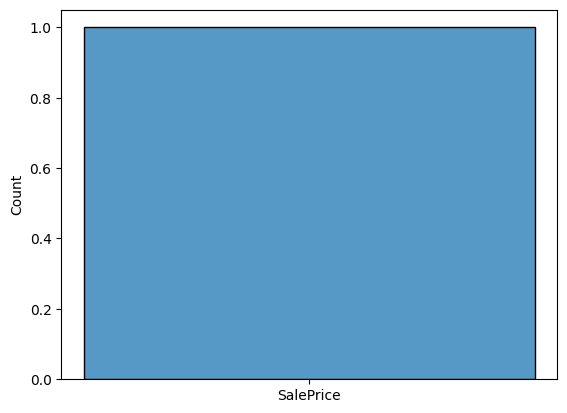

In [986]:
# Histogram ile bakis
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(["SalePrice"], bins=50)
plt.show()

# 2.0 🧹 VERİ ÖN İŞLEME

## 2.1 Eksik Veri Yönetimi

In [987]:
# en az 1 adet eksik degeri olan featurelari gorduk
null_df = train.isnull().sum().sort_values(ascending=False)
null_df[null_df>0]

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [988]:
null_df_test =test.isnull().sum().sort_values(ascending=False)
null_df_test[null_df>0]

,0
PoolQC,1456
MiscFeature,1408
Alley,1352
Fence,1169
MasVnrType,894
FireplaceQu,730
LotFrontage,227
GarageYrBlt,78
GarageCond,78
GarageFinish,78


In [989]:
# Ozellikleri inceleyerek nasil doldurmamiz veya gerekirse silmemiz gerektigine karar verelim
null_cols = null_df.index
train[null_cols]

,PoolQC,MiscFeature,Alley,Fence,MasVnrType,FireplaceQu,LotFrontage,GarageQual,GarageFinish,GarageType,...,OpenPorchSF,WoodDeckSF,PoolArea,ScreenPorch,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,NaN,NaN,NaN,NaN,BrkFace,NaN,65.0,TA,RFn,Attchd,...,61,0,0,0,0,2,2008,WD,Normal,208500
1,NaN,NaN,NaN,NaN,NaN,TA,80.0,TA,RFn,Attchd,...,0,298,0,0,0,5,2007,WD,Normal,181500
2,NaN,NaN,NaN,NaN,BrkFace,TA,68.0,TA,RFn,Attchd,...,42,0,0,0,0,9,2008,WD,Normal,223500
3,NaN,NaN,NaN,NaN,NaN,Gd,60.0,TA,Unf,Detchd,...,35,0,0,0,0,2,2006,WD,Abnorml,140000
4,NaN,NaN,NaN,NaN,BrkFace,TA,84.0,TA,RFn,Attchd,...,84,192,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,NaN,NaN,NaN,NaN,NaN,TA,62.0,TA,RFn,Attchd,...,40,0,0,0,0,8,2007,WD,Normal,175000
1456,NaN,NaN,NaN,MnPrv,Stone,TA,85.0,TA,Unf,Attchd,...,0,349,0,0,0,2,2010,WD,Normal,210000
1457,NaN,Shed,NaN,GdPrv,NaN,Gd,66.0,TA,RFn,Attchd,...,60,0,0,0,2500,5,2010,WD,Normal,266500
1458,NaN,NaN,NaN,NaN,NaN,NaN,68.0,TA,Unf,Attchd,...,0,366,0,0,0,4,2010,WD,Normal,142125


In [990]:
# Asiri fazla bos deger varsa bunlari silmek daha mantikli cunku karsilastirilacak bir karsit veri de yok.
missing_ratio = train.isnull().sum() / len(train)
high_missing = missing_ratio[missing_ratio > 0.9]
high_missing

,0
Alley,0.937671
PoolQC,0.995205
MiscFeature,0.963014


In [991]:
drop_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley"
]

train = train.drop(columns=drop_cols)

In [992]:
test = test.drop(columns=drop_cols)

In [994]:
# Garage feature'ları
garage_cols = [
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond"
]

# Basement feature'ları
bsmt_cols = [
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

# Diğerleri
train["Fence"] = train["Fence"].fillna("None")
train["FireplaceQu"] = train["FireplaceQu"].fillna("None")

train[bsmt_cols] = train[bsmt_cols].fillna("None")
train[garage_cols] = train[garage_cols].fillna("None")
# LotFrontage -> median
train["LotFrontage"] = train["LotFrontage"].fillna(train["LotFrontage"].median())

# Electrical -> mode
train["Electrical"] = train["Electrical"].fillna(train["Electrical"].mode()[0])

# MasVnrArea -> 0
train["MasVnrArea"] = train["MasVnrArea"].fillna(0)
train["MasVnrType"] = train["MasVnrType"].fillna("None")
train["GarageYrBlt"] = train["GarageYrBlt"].fillna(0)

In [995]:
# Garage feature'ları
garage_cols = [
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond"
]

# Basement feature'ları
bsmt_cols = [
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

# Diğer categorical boşlar
test["Fence"] = test["Fence"].fillna("None")
test["FireplaceQu"] = test["FireplaceQu"].fillna("None")

# Basement
test[bsmt_cols] = test[bsmt_cols].fillna("None")

# Garage
test[garage_cols] = test[garage_cols].fillna("None")

# Numerical doldurmalar
test["LotFrontage"] = test["LotFrontage"].fillna(test["LotFrontage"].median())

test["MasVnrArea"] = test["MasVnrArea"].fillna(0)
test["GarageYrBlt"] = test["GarageYrBlt"].fillna(0)

# Categorical doldurmalar
test["MasVnrType"] = test["MasVnrType"].fillna("None")
# Mode ile doldurulacak categorical kolonlar
mode_cols = [
    "MSZoning",
    "Utilities",
    "Functional",
    "Exterior2nd",
    "KitchenQual",
    "Exterior1st",
    "SaleType"
]

for col in mode_cols:
    test[col] = test[col].fillna(train[col].mode()[0])


# Sayısal kolonlar -> median
median_cols = [
    "BsmtHalfBath",
    "BsmtFullBath",
    "GarageCars",
    "BsmtUnfSF",
    "BsmtFinSF2",
    "BsmtFinSF1",
    "TotalBsmtSF",
    "GarageArea"
]

for col in median_cols:
    test[col] = test[col].fillna(train[col].median())

In [996]:
# Hic bir null degerimiz kalmadi buyukten kucuge siralama ile baktik
train.isnull().sum().sort_values(ascending=False).head(10)

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
LotShape,0
LandContour,0
Utilities,0
LotConfig,0


In [997]:
test.isnull().sum().sort_values(ascending=False).head(10)

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
LotShape,0
LandContour,0
Utilities,0
LotConfig,0


## 2.2 Aykırı Değer Tespiti (Outliers)

In [998]:
# Kolaylik olmasi acisindan bir fonksiyon ile yapicaz IQR kullanucaz.
def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]

    return df

In [999]:
# Outlier uygulamak icin bu feature lar secildi
outlier_cols = [
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "LotArea",
    "GarageArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "ScreenPorch",
    "MiscVal"
]
train = remove_outliers_iqr(train, outlier_cols)

# 3.0 🔎 FEATURE SELECTION

## 3.1 Model Karmasikligini azalt

In [1001]:
# Cok yuksek korelasyona sahip ama ayni zamanda ezber yapmayacagini dusundugumuz icin bu ozellikler ozellikle lineer icin guclu featurelar
# Non-lineer olan feature lar da var guclu olan
strong_sale_corr

,SalePrice
OverallQual,0.790982
TotalBsmtSF,0.613581
1stFlrSF,0.605852
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431


In [1002]:
# Sonucumuz icin herhangi bir bilgi tasimayan gereksiz featurelari eliyoruz
drop_cols = [
    "Id",
    "MoSold",
    "YrSold",
    "MiscVal",
    "PoolArea",
    "Utilities",
    "Street",
    "Condition2",
    "3SsnPorch",
    "ScreenPorch",
    "EnclosedPorch",
    "LowQualFinSF"
]

train = train.drop(columns=drop_cols)

In [1003]:
test = test.drop(columns=drop_cols)

## 3.2 Kategorik Değişken Dönüşümü

In [1005]:
# Feturelari uygun olan sekilde donusumlerini yapiyoruz


# -----------------------------
# ORDINAL MAPLER
# -----------------------------

qual_map = {
    "Ex": 5,
    "Gd": 4,
    "TA": 3,
    "Fa": 2,
    "Po": 1,
    "None": 0
}

fin_map = {
    "GLQ": 6,
    "ALQ": 5,
    "BLQ": 4,
    "Rec": 3,
    "LwQ": 2,
    "Unf": 1,
    "None": 0
}

garage_finish_map = {
    "Fin": 3,
    "RFn": 2,
    "Unf": 1,
    "None": 0
}

bsmt_exposure_map = {
    "Gd": 4,
    "Av": 3,
    "Mn": 2,
    "No": 1,
    "None": 0
}

# -----------------------------
# ORDINAL COLUMNS
# -----------------------------

ordinal_map_cols = {
    "ExterQual": qual_map,
    "ExterCond": qual_map,
    "BsmtQual": qual_map,
    "BsmtCond": qual_map,
    "HeatingQC": qual_map,
    "KitchenQual": qual_map,
    "FireplaceQu": qual_map,
    "GarageQual": qual_map,
    "GarageCond": qual_map,
    "BsmtExposure": bsmt_exposure_map,
    "BsmtFinType1": fin_map,
    "BsmtFinType2": fin_map,
    "GarageFinish": garage_finish_map
}


# LandSlope (ordinal)
train["LandSlope"] = train["LandSlope"].map({
    "Gtl": 1,
    "Mod": 2,
    "Sev": 3
})

# Fence (ordinal)
train["Fence"] = train["Fence"].fillna("None")
train["Fence"] = train["Fence"].map({
    "None": 0,
    "MnWw": 1,
    "GdWo": 2,
    "MnPrv": 3,
    "GdPrv": 4
})
# LandSlope
test["LandSlope"] = test["LandSlope"].map({
    "Gtl": 1,
    "Mod": 2,
    "Sev": 3
})

# Fence
test["Fence"] = test["Fence"].fillna("None")

test["Fence"] = test["Fence"].map({
    "None": 0,
    "MnWw": 1,
    "GdWo": 2,
    "MnPrv": 3,
    "GdPrv": 4
})

# -----------------------------
# ONE-HOT COLUMNS
# -----------------------------

onehot_cols = [
    "MSZoning","LotShape", "LandContour",
    "LotConfig", "Neighborhood",
    "Condition1","BldgType", "HouseStyle",
    "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd",
    "MasVnrType", "Foundation", "Heating", "CentralAir",
    "Electrical", "Functional", "GarageType",
    "PavedDrive", "SaleType", "SaleCondition"
]

In [1006]:
for col, mapping in ordinal_map_cols.items():
    train[col] = train[col].fillna("None")
    train[col] = train[col].map(mapping)
for col, mapping in ordinal_map_cols.items():
    test[col] = test[col].fillna("None")
    test[col] = test[col].map(mapping)

In [1007]:

train_features = train.drop("SalePrice", axis=1)

# Train ve Test'i birleştir (sadece feature'lar)
all_features = pd.concat([train_features, test], axis=0)

# One-hot encoding'i birleşik veri üzerinde yap
all_features = pd.get_dummies(all_features, columns=onehot_cols, drop_first=True)

In [1008]:
# Kontrol edelim her sey tamamen sayisal mi
train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,Fence,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Reg,Lvl,Inside,1,CollgCr,Norm,...,548,3,3,Y,0,61,0,WD,Normal,208500
1,20,RL,80.0,9600,Reg,Lvl,FR2,1,Veenker,Feedr,...,460,3,3,Y,298,0,0,WD,Normal,181500
2,60,RL,68.0,11250,IR1,Lvl,Inside,1,CollgCr,Norm,...,608,3,3,Y,0,42,0,WD,Normal,223500
4,60,RL,84.0,14260,IR1,Lvl,FR2,1,NoRidge,Norm,...,836,3,3,Y,192,84,0,WD,Normal,250000
6,20,RL,75.0,10084,Reg,Lvl,Inside,1,Somerst,Norm,...,636,3,3,Y,255,57,0,WD,Normal,307000


## 3.3 Verileri Normalize Et

In [1013]:
X_train = all_features.iloc[:len(train_features)]
X_test = all_features.iloc[len(train_features):]
y_train = train["SalePrice"]

In [1011]:
print(X_train.select_dtypes(include="object").columns)
print(X_test.select_dtypes(include="object").columns)

Index([], dtype='object')
Index([], dtype='object')


In [1012]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [1014]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=None, num_parallel_tree=None, ...)

In [1015]:
preds = model.predict(X_test_scaled)